<a href="https://colab.research.google.com/github/headdown0845/2026_First-semester_datamanagement-theory/blob/main/260424_2355022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [2]:
X, y, _ = make_regression(n_samples=50,
		    n_features=1, noise=50,
		    coef=True, random_state=11)
X, y = X.squeeze(), y.squeeze()

In [3]:
alpha, beta, data = 0, 0, []

In [4]:
for _ in range(50):
    for row in range(len(X)):
        y_hat = alpha + beta * X[row]
        error = y_hat - y[row]
        alpha -= 0.01 * error
        beta  -= 0.01 * error * X[row]
        data.append([alpha, beta, y_hat, y[row], error])

In [5]:
data = pd.DataFrame(data, columns=['alpha', 'beta', 'y_hat', 'y', 'error'])
last_epoch = data.iloc[-len(X):].reset_index(drop=True) # 마지막 epoch
final = last_epoch[['y', 'y_hat', 'error']]

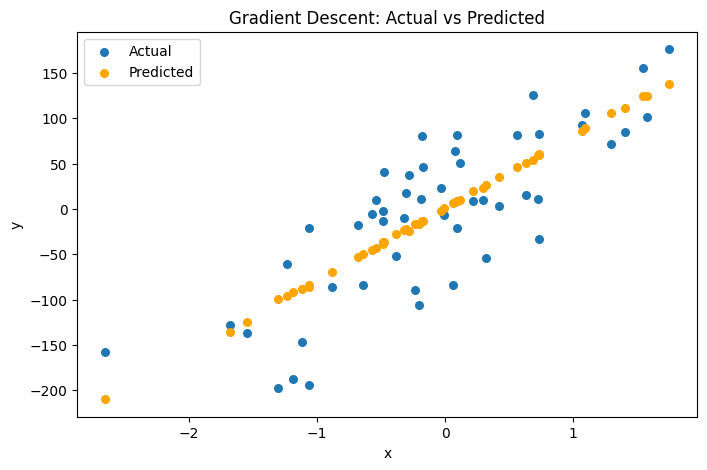

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=30, label='Actual')
plt.scatter(X, final['y_hat'], s=30, color='orange', label='Predicted')
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.title("Gradient Descent: Actual vs Predicted")
plt.show()

In [7]:
X, y, w = make_regression(n_samples=50,
			n_features=1,
			noise=15,
			coef=True,
			random_state=11)

In [8]:
import numpy as np

def sigmoid(x):
     return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def feedforward(X, w, b):
    sum = np.dot(X, w) + b #내적
    pred = sigmoid(sum)
    return sum, pred

def backpropagation(X, y, sum, pred, w, b):
    dsum = (pred - y) * sigmoid_derivative(sum)
    dw = np.dot(X.T, dsum)
    db = np.sum(dsum, axis=0)
    loss = np.mean((y - pred) ** 2)
    if (epoch + 1) % 100 == 0:
        print("loss: ", loss)

    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w, b

In [9]:
# define input and output
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[1]])

# define weights and biases
w = np.array([[1.5], [1.5]])
b = np.array([-1.5])

epochs = 1000  # 1000
learning_rate = 0.1

# train the network
for epoch in range(epochs):
    sum, pred = feedforward(X, w, b)
    w, b = backpropagation(X, y, sum, pred, w, b)

print("w:", w)
print("b:", b)

# print the final output
sum, pred = np.round(feedforward(X, w, b))
print(pred)
print("Accuracy:", np.mean(y == pred))

loss:  0.04564107081491127
loss:  0.03681832106416337
loss:  0.030846770013260746
loss:  0.026371158198747094
loss:  0.02291640511193708
loss:  0.020186602425775295
loss:  0.01798618066496532
loss:  0.016181758335233023
loss:  0.014679878681738442
loss:  0.013413472286458752
w: [[3.67260122]
 [3.67260122]]
b: [-1.54227573]
[[0.]
 [1.]
 [1.]
 [1.]]
Accuracy: 1.0


In [10]:
X, y, w = make_regression(n_samples=50,
			n_features=1,
			noise=15,
			coef=True,
			random_state=11)

In [14]:
import sympy as sp
w, b = sp.symbols('w b')
x_vals = [1, 2, 3, 4, 5]
y_vals = [2.1, 3.9, 6.2, 8.1, 10.1]
n = len(x_vals)

loss = 0
for i in range(n):
    prediction = w * x_vals[i] + b
    loss += (prediction - y_vals[i])**2
    loss = loss / n    # MSE
print(loss)

(b + w - 2.1)**2/3125 + (b + 2*w - 3.9)**2/625 + (b + 3*w - 6.2)**2/125 + (b + 4*w - 8.1)**2/25 + (b + 5*w - 10.1)**2/5


In [15]:
diff_w = sp.diff(loss, w)
diff_b = sp.diff(loss, b)

print(f"w에 대한 미분식: {diff_w}")
print(f"b에 대한 미분식: {diff_b}")

solution = sp.solve((diff_w, diff_b), (w, b))

print(f"최적의 기울기 (w): {solution[w]:.4f}")
print(f"최적의 절편 (b): {solution[b]:.4f}")

w에 대한 미분식: 7422*b/3125 + 35742*w/3125 - 23.115904
b에 대한 미분식: 1562*b/3125 + 7422*w/3125 - 4.801024
최적의 기울기 (w): 1.9932
최적의 절편 (b): 0.1344


In [16]:
import sympy

#  변수 및 함수 선언
a, b, x, y = sympy.symbols('a b x y')
L = sympy.Rational(1, 2) * (a + b * x - y)**2

# 2. 편미분 계산
grad_a = sympy.diff(L, a) # a에 대해 편미분
grad_b = sympy.diff(L, b) # b에 대해 편미분
# 3. 결과 출력
print(f"dL/d_a: {grad_a}")
print(f"dL/d_b : {grad_b}")

dL/d_a: a + b*x - y
dL/d_b : x*(a + b*x - y)


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y, _ = make_regression(n_samples=50, n_features=1, noise=50,
		    coef=True, random_state=11)
X, y = X.squeeze(), y.squeeze()

alpha, beta, data = 0, 0, []

for _ in range(50):
    for row in range(len(X)):
        y_hat = alpha + beta * X[row]
        error = y_hat - y[row]
        alpha -= 0.01 * error
        beta -= 0.01 * error * X[row]
        data.append([alpha, beta, y_hat, y[row], error])

data = pd.DataFrame(data, columns=['alpha', 'beta', 'y_hat', 'y', 'error'])
last_epoch = data.iloc[-len(X):].reset_index(drop=True) # 마지막 epoch
final = last_epoch[['y', 'y_hat', 'error']]

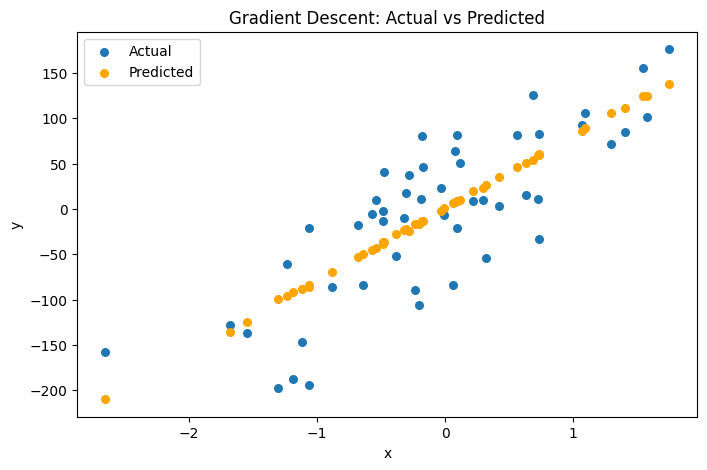

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=30, label='Actual')
plt.scatter(X, final['y_hat'], s=30, color='orange', label='Predicted')
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.title("Gradient Descent: Actual vs Predicted")
plt.show()

In [19]:
X, y, _ = make_regression(n_samples=50,
			n_features=1,
			noise=15,
			coef=True,
			random_state=11)

In [21]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
result = np.dot(a, b)

In [24]:
result

np.int64(32)

In [25]:
A = np.array([[1, 2], [3, 4]]) # (2, 2)
x = np.array([5, 6])           # (2,)
result = np.dot(A, x)
result

array([17, 39])

In [26]:
x = np.array([1, 2])           # (2,)
A = np.array([[3, 4], [5, 6]]) # (2, 2)
result = np.dot(x, A)
result

array([13, 16])

In [27]:
A = np.array([[1, 2], [3, 4]]) # (2, 2)
B = np.array([[5, 6], [7, 8]]) # (2, 2)
result = np.dot(A, B)
result

array([[19, 22],
       [43, 50]])

In [28]:
a = np.array([1.0, 2.0, 3.0])
# b = np.array([2.0, 2.0, 2.0])
b = 2.0
a * b

array([2., 4., 6.])

In [30]:
a = np.array([[ 0.0, 0.0, 0.0],
            [10.0, 10.0, 10.0],
            [20.0, 20.0, 20.0],
            [30.0, 30.0, 30.0]])
b = np.array([1.0, 2.0, 3.0])
a + b




array([[ 1.,  2.,  3.],
       [11., 12., 13.],
       [21., 22., 23.],
       [31., 32., 33.]])

In [34]:
import numpy as np
a = np.array([0.0, 10.0, 20.0, 30.0])
b = np.array([1.0, 2.0, 3.0])

a[:, np.newaxis] + b
a.reshape(-1,1) + b


array([[ 1.,  2.,  3.],
       [11., 12., 13.],
       [21., 22., 23.],
       [31., 32., 33.]])

In [35]:
from numpy import array, argmin, sqrt, sum
observation = array([111.0, 188.0])
codes = array([[102.0, 203.0],
            [132.0, 193.0],
            [45.0, 155.0],
            [57.0, 173.0]])
diff = codes - observation
dist = sqrt(sum(diff**2,axis=-1))
argmin(dist)

np.int64(0)